# 📡 QQQ — Investigación de Permanencia y Calidad de las Operaciones

## Parte 4 — Investigación de la Permanencia de las Operaciones

---

**Objetivo:** comprender por qué algunas operaciones generadas por las estrategias de la parte 3, pese a presentar duraciones similares, terminan obteniendo resultados finales muy distintos.

**Contexto:** La Parte 3 concluyó con la validación de dos estrategias finalistas (Champions), cada una representando un perfil operacional distinto. Durante dicha validación surgió un fenómeno que motivó esta investigación: algunas operaciones permanecen abiertas durante decenas o incluso cientos de semanas y obtienen retornos extraordinarios, mientras que otras, con permanencias comparables, terminan siendo poco rentables o claramente perdedoras.

Este notebook investiga ese comportamiento desde una perspectiva descriptiva. No modifica el modelo, no incorpora nuevas reglas operativas ni busca optimizar parámetros. Su propósito es comprender el comportamiento interno de las operaciones generadas por las estrategias finalistas antes de proponer cualquier mejora en etapas posteriores del proyecto.

---
---

## 🗺️ Mapa del Notebook

|      # | Sección                                                                                 | Contenido                                                                              |
| -----: | --------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
|  **0** | **Setup y Estado Canónico**                                                             | Carga y verificación del estado canónico generado por la Parte 3.5                     |
|  **1** | **Construcción del Universo de Investigación**                                          | Extracción y preparación de las operaciones de ambos Champions                         |
|  **2** | **Clasificación de Operaciones**                                                        | Clasificación por duración y calidad del resultado (CAGR)                              |
|  **3** | **Estadísticas Descriptivas por Grupo**                                                 | Caracterización inicial por duración y rentabilidad                                    |
|  **4** | **Variables Internas al Momento de Entrada**                                            | Comparación de variables de entrada entre grupos de rentabilidad                       |
|  **5** | **Evolución Temporal Dentro de la Operación**                                           | Trayectorias promedio de las variables internas alineadas por semanas desde la entrada |
|  **6** | **Diagnóstico del Holding**                                                             | Cuantificación del efecto del holding sobre la permanencia de las operaciones          |
|  **7** | **Diagnóstico del Régimen**                                                             | Velocidad de cambio de `meta_state` y evolución de `cluster_prob`                      |
|  **8** | **Mercados Laterales**                                                                  | Momentum y volatilidad en operaciones de duración media y larga                        |
|  **9** | **Señales Tempranas de Pérdidas Extremas**                                              | Identificación de señales tempranas en operaciones con pérdidas extremas               |
| **10** | **Timeline visual de las operaciones**                                                  | Visualización integrada de todas las operaciones sobre la serie histórica del QQQ      |
| **11** | **Conclusiones Finales**                                                                | Síntesis integrada de la evidencia y evaluación de las hipótesis de investigación      |



---

# ⚙️ Parte 0 — Setup y Carga del Estado Canónico

### BLOQUE 0 — Carga del Estado Canónico generado por la Parte 3.5

A partir de la nueva arquitectura del proyecto, esta etapa ya no reconstruye ningún componente del estado operativo. El universo completo —incluyendo el modelo, el histórico scoreado, el live_df, las operaciones y los paneles— es construido y congelado por la Parte 3.5, único productor autorizado del Estado Canónico.

La Parte 4, por tanto, realiza sobre ellos la investigación descriptiva: carga los artefactos persistidos por
la Parte 3.5 en `qqq_p4_cache/`, verifica que existan y que el universo sea consistente,
y ejecuta sobre ellos la investigación descriptiva sin recalcular señales, sin reentrenar
modelos y sin reconstruir operaciones.

En este bloque se cargan:

- el histórico scoreado completo (`scored_history`);
- el universo operativo (`live_df`);
- el resumen de operaciones del OR Champion (`or_trades`);
- los paneles temporales por operación (`or_panels`);
- la metadata del estado (`metadata`);
- y el bundle de inferencia del modelo (`model_artifacts`).

> **Secuencia del pipeline:** Parte 1 → Parte 2 → Parte 3 → **Parte 3.5** → **Parte 4**.
> Si los artefactos no existen, este notebook se detiene con un mensaje claro: la
> construcción del estado es responsabilidad exclusiva de la Parte 3.5.


In [37]:
# ============================================================
# BLOQUE 0 — IMPORTS, ESTILO Y RUTAS DEL ESTADO CANÓNICO
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

import joblib

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

NAVY, TEAL, GREEN, AMBER, RED, MUTED, BG = (
    "#0D1B2A", "#1B998B", "#2ECC71", "#F39C12", "#E74C3C", "#6B7A8D", "#EEF1F5"
)

# ── Parámetros operativos congelados — informativos, idénticos a la Parte 3.5 ──
#    (la Parte 4 NO los usa para recalcular nada; quedan disponibles por trazabilidad)
DD_RANK_THRESHOLD      = 0.65
DD_HOLD_WEEKS          = 4
STATE_SCORE_WEIGHTS    = {"atr": 0.0, "bull": 0.6, "trend": 0.4}
STATE_SCORE_PCT_THRESH = 0.70
STATE_HOLD_WEEKS       = 8

# ── Estado canónico — mismos nombres de archivo que produce la Parte 3.5 ──
CACHE_DIR = Path("./qqq_p4_cache")

ARTIFACTS = {
    "scored_history":  CACHE_DIR / "scored_history.pkl",
    "live_df":         CACHE_DIR / "live_df.pkl",
    "or_trades":       CACHE_DIR / "or_trades.pkl",
    "or_panels":       CACHE_DIR / "or_panels.pkl",
    "metadata":        CACHE_DIR / "metadata.pkl",
    "model_artifacts": CACHE_DIR / "model_artifacts.joblib",
}

def load_pickle(path: Path):
    with open(path, "rb") as f:
        return pickle.load(f)

print("✅ Imports, estilo y rutas listos.")
print(f"   Estado canónico: {CACHE_DIR.resolve()}")


✅ Imports, estilo y rutas listos.
   Estado canónico: C:\Users\planr\OneDrive\Escritorio\Guardar\Análisis de Inversiones\Trading Algoritmico\Bot Swing QQQ\QQQ Regimen 01\qqq_p4_cache


In [38]:
# ============================================================
# BLOQUE 0 — CARGA DEL ESTADO CANÓNICO
# ============================================================
#
# La Parte 4 NO reconstruye el estado. Si algún artefacto falta, se detiene:
# la construcción del estado es responsabilidad exclusiva de la Parte 3.5.
# ============================================================

# El estado operativo que la investigación descriptiva necesita son tres objetos:
# live_df, or_trades y or_panels (los produce la Parte 3.5 y son OBLIGATORIOS).
# El resto son complementos: scored_history y metadata son informativos, y
# model_artifacts pertenece a la capa de modelado (puede estar pendiente durante la
# transición). Todos ellos se cargan si existen, pero no bloquean la investigación.
REQUIRED_ARTIFACTS = ["live_df", "or_trades", "or_panels"]
OPTIONAL_ARTIFACTS = ["scored_history", "metadata", "model_artifacts"]

def load_canonical_state():
    missing = [name for name in REQUIRED_ARTIFACTS if not ARTIFACTS[name].exists()]
    if missing:
        faltan = ", ".join(missing)
        raise FileNotFoundError(
            "No se encontró el estado operativo canónico (faltan: "
            f"{faltan}).\n"
            "La construcción del estado es responsabilidad de la Parte 3.5. "
            "Ejecuta primero QQQ_Regime_Research_Parte_3.5.ipynb para generar los "
            f"artefactos en {CACHE_DIR.resolve()} y vuelve a ejecutar esta etapa."
        )

    state = {name: load_pickle(ARTIFACTS[name]) for name in REQUIRED_ARTIFACTS}

    # Complementos opcionales 
    for name in OPTIONAL_ARTIFACTS:
        if not ARTIFACTS[name].exists():
            state[name] = None
        elif name == "model_artifacts":
            state[name] = joblib.load(ARTIFACTS[name])
        else:
            state[name] = load_pickle(ARTIFACTS[name])
    return state


_state = load_canonical_state()

live_df         = _state["live_df"]
or_trades       = _state["or_trades"]
or_panels       = _state["or_panels"]
scored_history  = _state["scored_history"]
metadata        = _state["metadata"]
model_artifacts = _state["model_artifacts"]

print("✅ Estado operativo canónico cargado desde la Parte 3.5:")
print(f"   live_df         : {len(live_df):,} semanas")
print(f"   or_trades       : {len(or_trades):,} operaciones")
print(f"   or_panels       : {len(or_panels):,} paneles")
_opt_status = lambda v, label: print(
    f"   {label:15s} : {'✅ disponible' if v is not None else '⏳ no disponible aún'}")
_opt_status(scored_history,  "scored_history")
_opt_status(metadata,        "metadata")
_opt_status(model_artifacts, "model_artifacts")


✅ Estado operativo canónico cargado desde la Parte 3.5:
   live_df         : 1,325 semanas
   or_trades       : 32 operaciones
   or_panels       : 32 paneles
   scored_history  : ✅ disponible
   metadata        : ✅ disponible
   model_artifacts : ✅ disponible


### Verificación

Antes de comenzar el análisis verificamos que el Estado Canónico cargado corresponde exactamente al universo de operaciones validado en la Parte 3 y posteriormente materializado por la Parte 3.5.

Esta comprobación garantiza que toda la investigación posterior se desarrolla sobre el mismo estado operativo validado, evitando reconstrucciones independientes o posibles divergencias respecto de la definición canónica del proyecto.

In [39]:
def count_events(df, col):
    sig = df[col].astype(int)
    block_id = (sig.diff().fillna(0) != 0).cumsum()
    return sum(1 for _, grp in df.groupby(block_id) if grp[col].iloc[0])

n_and = count_events(live_df, "and_active")
n_or  = count_events(live_df, "or_active")
print(f"Operaciones AND reconstruidas: {n_and}")
print(f"Operaciones OR  reconstruidas: {n_or}")

Operaciones AND reconstruidas: 12
Operaciones OR  reconstruidas: 32


# 🧱 Parte 1 — Construcción del Universo de Investigación Construcción del Universo de Investigación

A partir del Estado Canónico, esta sección construye el universo de operaciones que será utilizado durante toda la investigación. Para ello, las señales activas de los dos Champions seleccionados en la Parte 3 —OR Champion y AND Champion— se transforman en operaciones individuales, preservando la información necesaria para su análisis posterior.

Cada operación conserva su fecha de entrada y salida, su duración, su rendimiento y la evolución completa de las variables internas del modelo mientras permaneció abierta. Además, todas las operaciones son clasificadas utilizando criterios comunes de duración y rentabilidad, estableciendo así un universo de investigación consistente para el desarrollo de las hipótesis posteriores.

In [40]:
# ============================================================
# CONSTRUCCIÓN DEL UNIVERSO — Trade lists de ambos Champions
# ============================================================

INTERNAL_VARS = [
    "cluster", "meta_state", "cluster_prob", "pred_prob_bull",
    "state_score_opt", "bull_rank", "trend_rank", "drawdown", "atr_pct",
    "mom_4", "mom_13", "mom_26", "mom_52", "trend_13_52", "vol_13",
    "score_dd_atr", "dd_raw", "dd_held", "opt_raw", "opt_held",
]
INTERNAL_VARS = [v for v in INTERNAL_VARS if v in live_df.columns]

def extract_trades(df, active_col, internal_vars=INTERNAL_VARS):
    """Extrae operaciones (bloques contiguos activos) con snapshot de
    entrada/salida/promedio de cada variable interna, más el panel temporal
    completo semana a semana (necesario para el análisis de evolución)."""
    sig = df[active_col].astype(int)
    block_id = (sig.diff().fillna(0) != 0).cumsum()
    trades, panels = [], {}
    for _, grp in df.groupby(block_id):
        if not grp[active_col].iloc[0]:
            continue
        tid = len(trades)
        entry_date, exit_date = grp.index[0], grp.index[-1]
        n_weeks   = len(grp)
        ret_total = grp["returns"].add(1).prod() - 1
        years     = max(n_weeks / 52, 1 / 52)
        cagr      = (1 + ret_total) ** (1 / years) - 1

        info = {
            "trade_id": tid, "entry": entry_date, "exit": exit_date,
            "weeks": n_weeks, "return": ret_total, "cagr": cagr,
            "en_curso": exit_date == df.index[-1],
        }
        for v in internal_vars:
            info[f"{v}_entry"] = grp[v].iloc[0]
            info[f"{v}_exit"]  = grp[v].iloc[-1]
            if pd.api.types.is_numeric_dtype(grp[v]):
                info[f"{v}_mean"] = grp[v].mean()
        trades.append(info)
        panels[tid] = grp[internal_vars + ["Close", "returns"]].copy()
    return pd.DataFrame(trades), panels

# Extracción única de ambos Champions (preparación del universo)
or_trades,  or_panels  = extract_trades(live_df, "or_active")
and_trades, and_panels = extract_trades(live_df, "and_active")

# ── Clasificación transversal: duración × rentabilidad (ambos Champions) ──
def classify_duration(weeks):
    if weeks < 12:    return "Cortas (<12s)"
    elif weeks <= 32: return "Medias (12-32s)"
    else:             return "Largas (>32s)"

CAGR_POCO_RENTABLE_MAX = 0.08   # convención descriptiva

def classify_profitability(cagr):
    if cagr < 0:                        return "Perdedora"
    elif cagr < CAGR_POCO_RENTABLE_MAX: return "Poco rentable"
    else:                               return "Muy rentable"

dur_order  = ["Cortas (<12s)", "Medias (12-32s)", "Largas (>32s)"]
prof_order = ["Perdedora", "Poco rentable", "Muy rentable"]
colors_box = {"Perdedora": RED, "Poco rentable": AMBER, "Muy rentable": GREEN}

for _t in (or_trades, and_trades):
    _t["duration_group"] = pd.Categorical(
        _t["weeks"].apply(classify_duration), dur_order, ordered=True)
    _t["profit_group"] = pd.Categorical(
        _t["cagr"].apply(classify_profitability), prof_order, ordered=True)

print(f"Universo de investigación construido:")
print(f"  OR  Champion : {len(or_trades):,} operaciones")
print(f"  AND Champion : {len(and_trades):,} operaciones")
print(f"  Variables internas por operación: {len(INTERNAL_VARS)}")
print(f"  Clasificación aplicada: duration_group x profit_group (ambos Champions)")


Universo de investigación construido:
  OR  Champion : 32 operaciones
  AND Champion : 12 operaciones
  Variables internas por operación: 20
  Clasificación aplicada: duration_group x profit_group (ambos Champions)


### 🎯 Presentación de los Champions

El universo de investigación está compuesto por las dos estrategias finalistas seleccionadas en la Parte 3: el OR Champion y el AND Champion. Antes de desarrollar las hipótesis, se presenta un resumen descriptivo de ambas estrategias, incluyendo el número de operaciones, el período cubierto y sus principales características operacionales.

Esta presentación tiene un carácter exclusivamente descriptivo. En esta etapa no se interpretan resultados ni se establecen comparaciones; su único propósito es contextualizar el universo de operaciones que será analizado en las secciones siguientes.


In [41]:
# ============================================================
# PRESENTACIÓN DE LOS CHAMPIONS — resumen descriptivo
# ============================================================

def champion_summary(trades, name):
    return {
        "Champion": name,
        "N operaciones": len(trades),
        "Primera entrada": trades["entry"].min().date() if len(trades) else None,
        "Última salida":   trades["exit"].max().date()  if len(trades) else None,
        "Duración media (sem)": round(trades["weeks"].mean(), 1) if len(trades) else None,
        "Duración máx (sem)":   int(trades["weeks"].max())      if len(trades) else None,
        "En curso": int(trades["en_curso"].sum()) if len(trades) else 0,
    }

resumen = pd.DataFrame([
    champion_summary(or_trades,  "OR Champion"),
    champion_summary(and_trades, "AND Champion"),
])
display(resumen)

print("Operaciones del OR Champion:")
display(or_trades[["trade_id", "entry", "exit", "weeks", "return", "cagr", "en_curso"]])

print("Operaciones del AND Champion:")
display(and_trades[["trade_id", "entry", "exit", "weeks", "return", "cagr", "en_curso"]])


,Champion,N operaciones,Primera entrada,Última salida,Duración media (sem),Duración máx (sem),En curso
0,OR Champion,32,2001-01-26,2026-06-12,30.3,200,1
1,AND Champion,12,2003-04-11,2022-05-06,8.6,24,0


Operaciones del OR Champion:


,trade_id,entry,exit,weeks,return,cagr,en_curso
0,0,2001-01-26,2004-11-19,200,-0.416473,-0.130688,False
1,1,2005-01-21,2005-02-11,4,-0.018995,-0.220666,False
2,2,2005-03-04,2005-05-06,10,-0.046784,-0.220538,False
3,3,2006-06-09,2006-09-22,16,0.007058,0.023123,False
4,4,2008-01-04,2009-11-27,100,-0.154083,-0.083335,False
5,5,2010-05-21,2010-10-01,20,0.050813,0.137537,False
6,6,2011-05-13,2011-07-01,8,-0.007357,-0.046861,False
7,7,2011-07-22,2012-02-24,32,0.111907,0.188123,False
8,8,2012-03-30,2012-05-18,8,-0.091575,-0.464352,False
9,9,2012-06-01,2013-03-01,40,0.097224,0.128194,False


Operaciones del AND Champion:


,trade_id,entry,exit,weeks,return,cagr,en_curso
0,0,2003-04-11,2003-07-25,16,0.220729,0.912108,False
1,1,2004-02-27,2004-04-16,8,-0.020891,-0.128229,False
2,2,2005-04-15,2005-04-22,2,-0.042303,-0.674968,False
3,3,2008-01-04,2008-04-18,16,-0.097906,-0.284569,False
4,4,2008-07-04,2008-08-22,8,0.040307,0.292851,False
5,5,2009-07-24,2009-09-11,8,0.105431,0.918478,False
6,6,2010-05-21,2010-07-09,8,-0.045547,-0.261408,False
7,7,2011-08-12,2012-01-20,24,0.116664,0.270082,False
8,8,2018-12-21,2019-01-04,3,-0.027334,-0.381456,False
9,9,2020-03-20,2020-04-10,4,0.046522,0.806040,False


### 🧭 Rol Metodológico de cada Champion

Existiendo dos estrategias finalistas, la investigación se desarrolla principalmente sobre el OR Champion. Esta decisión responde exclusivamente a un criterio metodológico y no a una mayor importancia relativa entre ambas estrategias. La anomalía que motiva esta Parte 4 —operaciones de duración comparable con resultados finales muy distintos— fue identificada durante el análisis del OR Champion al finalizar la Parte 3. Por ello, el OR constituye el caso principal de estudio.

El AND Champion se utiliza como **evidencia complementaria**. En cada hipótesis, una vez presentada la evidencia principal sobre el OR, se incorpora el AND Champion cuando la metodología y la evidencia disponible lo permitan, con el propósito de evaluar si el mismo patrón también se observa en la estrategia complementaria. si el patrón observado también aparece bajo el AND. Esa evidencia complementaria puede fortalecer, matizar o dejar abierta la conclusión de cada hipótesis, pero no reemplaza ni domina la evidencia obtenida sobre el caso principal.

Con el universo de estudio construido y presentado, y definido el rol de cada Champion, se inicia el desarrollo de las hipótesis de investigación.


# 🟦 Sección 2 — Clasificación de Operaciones

Una vez extraídas las operaciones del **OR Champion**, es necesario establecer criterios de clasificación que permitan organizarlas y compararlas de forma consistente durante el resto de la investigación.

La investigación analizará las operaciones desde dos perspectivas independientes:

### Por duración

La **duración** de cada operación permite distinguir si permaneció poco tiempo en el mercado o si logró sostenerse durante un período prolongado.

* **Cortas:** menos de 12 semanas
* **Medias:** entre 12 y 32 semanas
* **Largas:** más de 32 semanas

### Por calidad del resultado

La **rentabilidad** de cada operación se evaluará mediante su **CAGR**, en lugar del retorno absoluto, ya que esta métrica permite comparar operaciones con distintas duraciones bajo una misma base anualizada.

Con este criterio las operaciones se clasifican en tres grupos:

* **Perdedoras:** CAGR < 0%
* **Poco rentables:** 0% ≤ CAGR < 8%
* **Muy rentables:** CAGR ≥ 8%

Ambas clasificaciones representan **dimensiones independientes del análisis**. En consecuencia, una operación larga puede resultar muy rentable, poco rentable o perdedora, del mismo modo que una operación corta puede pertenecer a cualquiera de estas categorías. La combinación de ambas dimensiones constituye la base de los análisis desarrollados en las secciones siguientes.


DISTRIBUCIÓN POR DURACIÓN


,N
duration_group,
Cortas (<12s),11
Medias (12-32s),14
Largas (>32s),7



DISTRIBUCIÓN POR RENTABILIDAD (CAGR)


,N
profit_group,
Perdedora,11
Poco rentable,2
Muy rentable,19



TABLA CRUZADA — Duración × Rentabilidad


profit_group,Perdedora,Poco rentable,Muy rentable
duration_group,,,
Cortas (<12s),6,0,5
Medias (12-32s),1,1,12
Largas (>32s),4,1,2


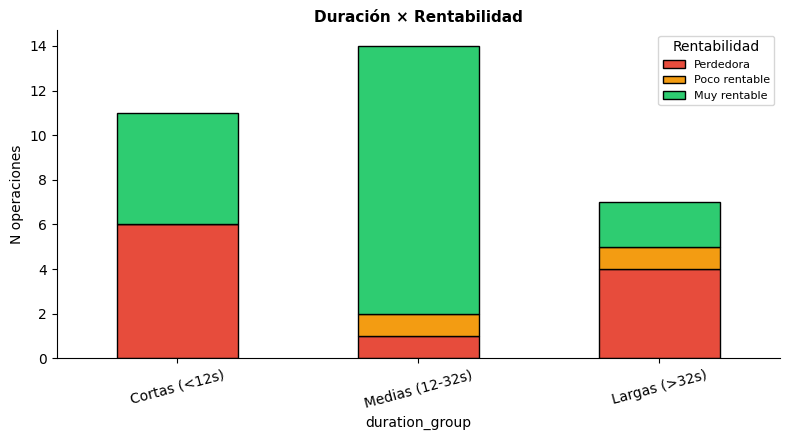

In [42]:
# ============================================================
# SECCIÓN 2 — CLASIFICACIÓN: DURACIÓN × RENTABILIDAD
# ============================================================

def classify_duration(weeks):
    if weeks < 12:   return "Cortas (<12s)"
    elif weeks <= 32: return "Medias (12-32s)"
    else:             return "Largas (>32s)"

CAGR_POCO_RENTABLE_MAX = 0.08   # convención descriptiva, documentada arriba

def classify_profitability(cagr):
    if cagr < 0:                       return "Perdedora"
    elif cagr < CAGR_POCO_RENTABLE_MAX: return "Poco rentable"
    else:                               return "Muy rentable"

or_trades["duration_group"] = or_trades["weeks"].apply(classify_duration)
or_trades["profit_group"]   = or_trades["cagr"].apply(classify_profitability)

dur_order  = ["Cortas (<12s)", "Medias (12-32s)", "Largas (>32s)"]
prof_order = ["Perdedora", "Poco rentable", "Muy rentable"]
or_trades["duration_group"] = pd.Categorical(or_trades["duration_group"], dur_order, ordered=True)
or_trades["profit_group"]   = pd.Categorical(or_trades["profit_group"],   prof_order, ordered=True)

print("DISTRIBUCIÓN POR DURACIÓN")
display(or_trades["duration_group"].value_counts().sort_index().to_frame("N"))

print("\nDISTRIBUCIÓN POR RENTABILIDAD (CAGR)")
display(or_trades["profit_group"].value_counts().sort_index().to_frame("N"))

print("\nTABLA CRUZADA — Duración × Rentabilidad")
cross = pd.crosstab(or_trades["duration_group"], or_trades["profit_group"])
display(cross)

fig, ax = plt.subplots(figsize=(8, 4.5))
cross.plot(kind="bar", stacked=True, ax=ax,
           color=[RED, AMBER, GREEN], edgecolor="black")
ax.set_title("Duración × Rentabilidad", fontsize=11, fontweight="bold")
ax.set_ylabel("N operaciones"); ax.legend(title="Rentabilidad", fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


### Operaciones **"Largas"** en detalle

Hasta este punto sabemos que existen operaciones que permanecen abiertas durante muchos meses. Sin embargo, **una mayor permanencia en el mercado no garantiza, por sí sola, un buen resultado**.

Antes de comenzar el análisis de las hipótesis, examinamos explícitamente todas las operaciones clasificadas como **Largas** junto con su rentabilidad final. Esta inspección descriptiva permite comprobar que existen operaciones con duraciones similares, pero resultados muy distintos, confirmando la existencia del fenómeno que motiva la investigación y justificando el análisis desarrollado en las secciones siguientes.


In [43]:
largas = or_trades[or_trades["duration_group"] == "Largas (>32s)"].copy()
print(f"Operaciones Largas (>32 semanas): {len(largas)}")
display(largas[["trade_id", "entry", "exit", "weeks", "return", "cagr", "profit_group"]]
        .sort_values("weeks", ascending=False))

print(f"\nDistribución de rentabilidad dentro de Largas:")
display(largas["profit_group"].value_counts().sort_index().to_frame("N"))

Operaciones Largas (>32 semanas): 7


,trade_id,entry,exit,weeks,return,cagr,profit_group
0,0,2001-01-26,2004-11-19,200,-0.416473,-0.130688,Perdedora
4,4,2008-01-04,2009-11-27,100,-0.154083,-0.083335,Perdedora
12,12,2014-07-25,2016-03-25,88,0.137451,0.079074,Poco rentable
29,29,2024-07-19,2025-11-28,72,0.259987,0.181644,Muy rentable
17,17,2018-02-09,2019-01-11,49,-0.015565,-0.016510,Perdedora
24,24,2021-10-01,2022-08-12,46,-0.111088,-0.124637,Perdedora
9,9,2012-06-01,2013-03-01,40,0.097224,0.128194,Muy rentable



Distribución de rentabilidad dentro de Largas:


,N
profit_group,
Perdedora,4
Poco rentable,1
Muy rentable,2


# 3️⃣ Estadísticas Descriptivas por Grupo

Antes de analizar las variables internas del modelo, resulta útil caracterizar los distintos grupos de operaciones desde una perspectiva general.

En esta sección se presentan las principales estadísticas descriptivas agrupadas por **duración** y **rentabilidad**, con el objetivo de responder preguntas como:

* ¿Qué grupo concentra más operaciones?
* ¿Cuánto tiempo permanecen abiertas, en promedio?
* ¿Qué rentabilidad generan?
* ¿Qué tan consistentes son sus resultados?

Estas estadísticas constituyen una primera caracterización del **OR Champion** y proporcionan el contexto necesario para interpretar los análisis específicos desarrollados en las secciones posteriores.


In [44]:
# ============================================================
# SECCIÓN 3 — ESTADÍSTICAS DESCRIPTIVAS POR GRUPO
# ============================================================

def group_stats(df, group_col):
    rows = []
    for g in df[group_col].cat.categories if hasattr(df[group_col], "cat") else df[group_col].unique():
        sub = df[df[group_col] == g]
        if len(sub) == 0:
            continue
        wins, losses = sub[sub["return"] > 0]["return"], sub[sub["return"] <= 0]["return"]
        pf = (wins.sum() / abs(losses.sum())) if len(losses) and losses.sum() != 0 else np.nan
        rows.append({
            "Grupo": g, "N": len(sub), "Duración media (sem)": sub["weeks"].mean(),
            "Retorno medio": sub["return"].mean(), "Retorno mediana": sub["return"].median(),
            "Máximo": sub["return"].max(), "Mínimo": sub["return"].min(),
            "Win rate": (sub["return"] > 0).mean(), "Profit factor": pf,
            "CAGR medio": sub["cagr"].mean(), "Semanas totales en mercado": sub["weeks"].sum(),
        })
    return pd.DataFrame(rows)

stats_duration = group_stats(or_trades, "duration_group")
stats_profit   = group_stats(or_trades, "profit_group")

print("POR GRUPO DE DURACIÓN")
display(stats_duration.round(4))

print("\nPOR GRUPO DE RENTABILIDAD")
display(stats_profit.round(4))

# ── Cruce: estadísticas dentro de Medias y Largas, por rentabilidad ──
print("\nDENTRO DE 'MEDIAS' — por rentabilidad")
display(group_stats(or_trades[or_trades["duration_group"]=="Medias (12-32s)"], "profit_group").round(4))

print("\nDENTRO DE 'LARGAS' — por rentabilidad")
display(group_stats(or_trades[or_trades["duration_group"]=="Largas (>32s)"], "profit_group").round(4))

POR GRUPO DE DURACIÓN


,Grupo,N,Duración media (sem),Retorno medio,Retorno mediana,Máximo,Mínimo,Win rate,Profit factor,CAGR medio,Semanas totales en mercado
0,Cortas (<12s),11,7.2727,0.0085,-0.0030,0.0828,-0.0916,0.4545,1.4239,0.0675,80
1,Medias (12-32s),14,21.1429,0.0968,0.0962,0.2297,-0.0823,0.9286,17.4673,0.2496,296
2,Largas (>32s),7,85.0000,-0.0289,-0.0156,0.2600,-0.4165,0.4286,0.7095,0.0048,595



POR GRUPO DE RENTABILIDAD


,Grupo,N,Duración media (sem),Retorno medio,Retorno mediana,Máximo,Mínimo,Win rate,Profit factor,CAGR medio,Semanas totales en mercado
0,Perdedora,11,41.3636,-0.0909,-0.0530,-0.0030,-0.4165,0.0,0.0,-0.2077,455
1,Poco rentable,2,52.0000,0.0723,0.0723,0.1375,0.0071,1.0,NaN,0.0511,104
2,Muy rentable,19,21.6842,0.1106,0.0840,0.2600,0.0351,1.0,NaN,0.3397,412



DENTRO DE 'MEDIAS' — por rentabilidad


,Grupo,N,Duración media (sem),Retorno medio,Retorno mediana,Máximo,Mínimo,Win rate,Profit factor,CAGR medio,Semanas totales en mercado
0,Perdedora,1,20.0000,-0.0823,-0.0823,-0.0823,-0.0823,0.0,0.0,-0.2000,20
1,Poco rentable,1,16.0000,0.0071,0.0071,0.0071,0.0071,1.0,NaN,0.0231,16
2,Muy rentable,12,21.6667,0.1192,0.1101,0.2297,0.0413,1.0,NaN,0.3059,260



DENTRO DE 'LARGAS' — por rentabilidad


,Grupo,N,Duración media (sem),Retorno medio,Retorno mediana,Máximo,Mínimo,Win rate,Profit factor,CAGR medio,Semanas totales en mercado
0,Perdedora,4,98.75,-0.1743,-0.1326,-0.0156,-0.4165,0.0,0.0,-0.0888,395
1,Poco rentable,1,88.00,0.1375,0.1375,0.1375,0.1375,1.0,NaN,0.0791,88
2,Muy rentable,2,56.00,0.1786,0.1786,0.2600,0.0972,1.0,NaN,0.1549,112


# 4️⃣ Variables Internas al Momento de Entrada

Hasta este punto hemos caracterizado las operaciones según su duración y su resultado final.

La siguiente pregunta de investigación es:

**¿Las operaciones que terminarán siendo muy rentables, poco rentables o perdedoras ya presentan diferencias al momento de la entrada, o esas diferencias aparecen únicamente durante su permanencia en el mercado?**

Si las diferencias ya existen desde la entrada, dichas variables podrían constituir candidatos naturales para futuros filtros de entrada.

Por el contrario, si todas las operaciones comienzan bajo condiciones similares y solo se diferencian con el paso del tiempo, la explicación del fenómeno probablemente no se encuentre en la entrada, sino en la forma en que el sistema mantiene abiertas las posiciones.

En esta sección se comparan las principales variables internas del modelo en el momento de entrada, con el objetivo de identificar evidencia de una posible separación temprana entre los distintos grupos de rentabilidad.


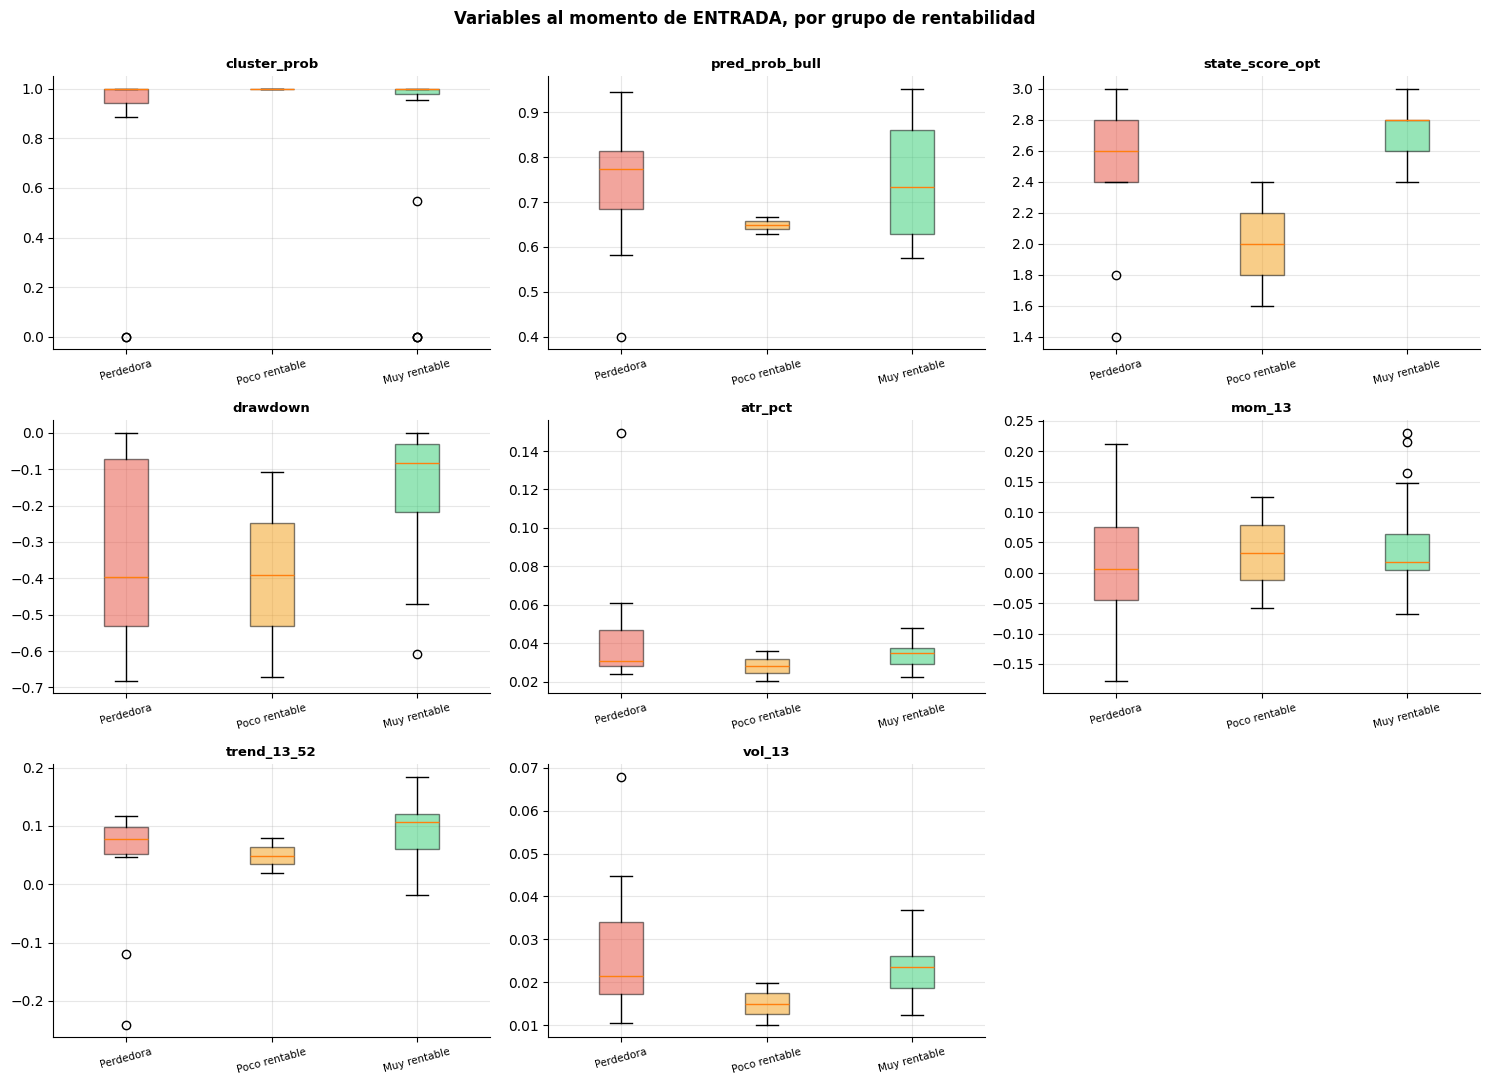


TEST MANN-WHITNEY — Muy rentable vs Perdedora (variables de entrada)
(no paramétrico, apropiado para muestras pequeñas; p<0.05 sugiere diferencia)


,Variable,N rentable,N perdedora,Media rentable,Media perdedora,p-value
0,cluster_prob_entry,19,11,0.8160,0.8077,0.9557
1,pred_prob_bull_entry,19,11,0.7470,0.7360,0.9314
2,state_score_opt_entry,19,11,2.7368,2.4727,0.1137
3,drawdown_entry,19,11,-0.1584,-0.3377,0.0674
4,atr_pct_entry,19,11,0.0343,0.0458,0.9314
5,mom_13_entry,19,11,0.0493,0.0192,0.3017
6,trend_13_52_entry,19,11,0.0879,0.0359,0.1213
7,vol_13_entry,19,11,0.0233,0.0281,0.8633



Variables con diferencia sugestiva (p<0.10): ['drawdown_entry']


In [45]:
# ============================================================
# SECCIÓN 4 — BOXPLOTS DE VARIABLES AL MOMENTO DE ENTRADA
# ============================================================

entry_vars = ["cluster_prob_entry", "pred_prob_bull_entry", "state_score_opt_entry",
              "drawdown_entry", "atr_pct_entry", "mom_13_entry", "trend_13_52_entry",
              "vol_13_entry"]
entry_vars = [v for v in entry_vars if v in or_trades.columns]

groups_for_box = [g for g in prof_order if (or_trades["profit_group"] == g).sum() >= 2]
colors_box = {"Perdedora": RED, "Poco rentable": AMBER, "Muy rentable": GREEN}

n_vars = len(entry_vars)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.6 * nrows))
axes = np.array(axes).flatten()

for ax, var in zip(axes, entry_vars):
    data = [or_trades[or_trades["profit_group"] == g][var].dropna() for g in groups_for_box]
    bp = ax.boxplot(data, labels=groups_for_box, patch_artist=True)
    for patch, g in zip(bp["boxes"], groups_for_box):
        patch.set_facecolor(colors_box.get(g, MUTED)); patch.set_alpha(0.5)
    ax.set_title(var.replace("_entry", ""), fontsize=9.5, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7.5, rotation=15)
    ax.grid(True, alpha=0.3)

for ax in axes[n_vars:]:
    ax.axis("off")

plt.suptitle("Variables al momento de ENTRADA, por grupo de rentabilidad", fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

# ── Test estadístico simple: Mann-Whitney entre Muy rentable y Perdedora ──
print("\nTEST MANN-WHITNEY — Muy rentable vs Perdedora (variables de entrada)")
print("(no paramétrico, apropiado para muestras pequeñas; p<0.05 sugiere diferencia)")
rentable = or_trades[or_trades["profit_group"] == "Muy rentable"]
perdedora = or_trades[or_trades["profit_group"] == "Perdedora"]
rows = []
for var in entry_vars:
    a, b = rentable[var].dropna(), perdedora[var].dropna()
    if len(a) >= 3 and len(b) >= 3:
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({"Variable": var, "N rentable": len(a), "N perdedora": len(b),
                     "Media rentable": a.mean(), "Media perdedora": b.mean(), "p-value": p})
mw_df = pd.DataFrame(rows)
if len(mw_df):
    display(mw_df.round(4))
    print("\nVariables con diferencia sugestiva (p<0.10):",
          mw_df[mw_df["p-value"] < 0.10]["Variable"].tolist() or "ninguna")
else:
    print("Muestra insuficiente para el test (se requieren ≥3 casos por grupo).")

### Evidencia complementaria — AND Champion

La misma verificación se aplica sobre el **AND Champion**, utilizando exactamente la misma metodología empleada para el **OR Champion**: las mismas variables de entrada, los mismos grupos de rentabilidad y los mismos criterios de interpretación.

Con el fin de mantener la comparabilidad entre ambos Champions, los criterios de suficiencia de evidencia también permanecen inalterados. En consecuencia, los gráficos se presentan únicamente cuando cada grupo dispone de al menos dos operaciones, mientras que el contraste estadístico de **Mann–Whitney** requiere un mínimo de tres operaciones por grupo. Cuando estas condiciones no se cumplen, la evidencia correspondiente se declara **no evaluable**, evitando forzar gráficos o pruebas cuya interpretación no sería metodológicamente consistente.


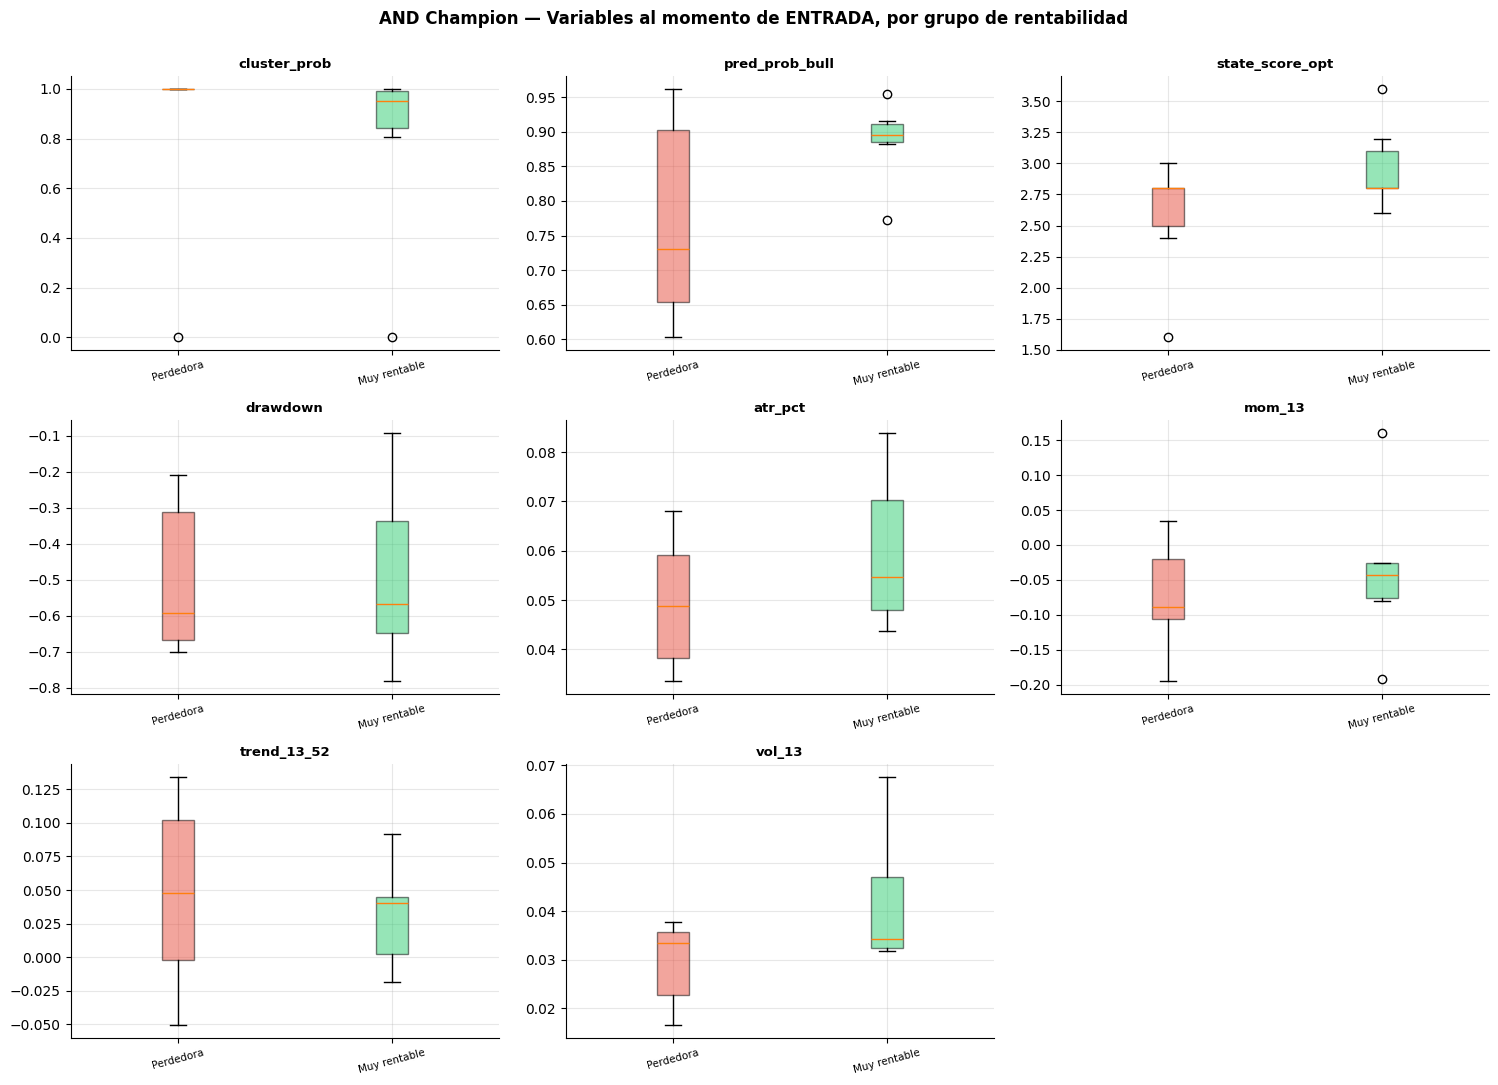


TEST MANN-WHITNEY — Muy rentable vs Perdedora (variables de entrada, AND Champion)
(no paramétrico, apropiado para muestras pequeñas; p<0.05 sugiere diferencia)


,Variable,N rentable,N perdedora,Media rentable,Media perdedora,p-value
0,cluster_prob_entry,6,6,0.7848,0.8333,0.2103
1,pred_prob_bull_entry,6,6,0.8859,0.7692,0.3939
2,state_score_opt_entry,6,6,2.9667,2.5667,0.3051
3,drawdown_entry,6,6,-0.4906,-0.5014,1.0000
4,atr_pct_entry,6,6,0.0597,0.0495,0.4848
5,mom_13_entry,6,6,-0.0373,-0.0745,0.4848
6,trend_13_52_entry,6,6,0.0317,0.0466,0.6991
7,vol_13_entry,6,6,0.0419,0.0294,0.4848



Variables con diferencia sugestiva (p<0.10): ninguna


In [46]:
# ============================================================
# SECCIÓN 4 — EVIDENCIA COMPLEMENTARIA: AND CHAMPION
# ============================================================

if "and_trades" not in globals():
    and_trades, and_panels = extract_trades(live_df, "and_active")
    and_trades["duration_group"] = and_trades["weeks"].apply(classify_duration)
    and_trades["profit_group"]   = and_trades["cagr"].apply(classify_profitability)
    and_trades["duration_group"] = pd.Categorical(and_trades["duration_group"], dur_order, ordered=True)
    and_trades["profit_group"]   = pd.Categorical(and_trades["profit_group"],   prof_order, ordered=True)
    print(f"Operaciones AND Champion extraídas: {len(and_trades)}")

# Mismas variables de entrada que en el análisis del OR
entry_vars_and = [v for v in entry_vars if v in and_trades.columns]

# Mismo criterio de graficado que el OR: grupos con al menos 2 operaciones
groups_for_box_and = [g for g in prof_order if (and_trades["profit_group"] == g).sum() >= 2]

if len(groups_for_box_and) >= 2:
    n_vars = len(entry_vars_and)
    ncols = 3
    nrows = int(np.ceil(n_vars / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.6 * nrows))
    axes = np.array(axes).flatten()

    for ax, var in zip(axes, entry_vars_and):
        data = [and_trades[and_trades["profit_group"] == g][var].dropna() for g in groups_for_box_and]
        bp = ax.boxplot(data, labels=groups_for_box_and, patch_artist=True)
        for patch, g in zip(bp["boxes"], groups_for_box_and):
            patch.set_facecolor(colors_box.get(g, MUTED)); patch.set_alpha(0.5)
        ax.set_title(var.replace("_entry", ""), fontsize=9.5, fontweight="bold")
        ax.tick_params(axis="x", labelsize=7.5, rotation=15)
        ax.grid(True, alpha=0.3)

    for ax in axes[n_vars:]:
        ax.axis("off")

    plt.suptitle("AND Champion — Variables al momento de ENTRADA, por grupo de rentabilidad",
                 fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()
else:
    print("Evidencia insuficiente para el contraste visual entre grupos de rentabilidad "
          "en el AND Champion (se requieren al menos dos grupos con ≥2 operaciones).")

# ── Test estadístico simple: Mann-Whitney entre Muy rentable y Perdedora ──
print("\nTEST MANN-WHITNEY — Muy rentable vs Perdedora (variables de entrada, AND Champion)")
print("(no paramétrico, apropiado para muestras pequeñas; p<0.05 sugiere diferencia)")
rentable_and  = and_trades[and_trades["profit_group"] == "Muy rentable"]
perdedora_and = and_trades[and_trades["profit_group"] == "Perdedora"]
rows = []
for var in entry_vars_and:
    a, b = rentable_and[var].dropna(), perdedora_and[var].dropna()
    if len(a) >= 3 and len(b) >= 3:
        u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({"Variable": var, "N rentable": len(a), "N perdedora": len(b),
                     "Media rentable": a.mean(), "Media perdedora": b.mean(), "p-value": p})
mw_and = pd.DataFrame(rows)
if len(mw_and):
    display(mw_and.round(4))
    print("\nVariables con diferencia sugestiva (p<0.10):",
          mw_and[mw_and["p-value"] < 0.10]["Variable"].tolist() or "ninguna")
else:
    print("Evidencia insuficiente para el test en el AND Champion "
          "(se requieren ≥3 operaciones por grupo).")


### Discusión integrada de la evidencia

La evidencia obtenida del **OR Champion** constituye la base principal para responder la pregunta de investigación, ya que corresponde al caso donde se observó originalmente la anomalía que motiva esta Parte 4. El análisis del **AND Champion** permite evaluar si el mismo patrón también se presenta bajo una estrategia distinta, utilizando una metodología equivalente.

En conjunto, ambas fuentes permiten valorar la consistencia del hallazgo. Cuando el AND reproduce el mismo comportamiento observado en el OR, la evidencia a favor de la hipótesis se fortalece. Cuando la corroboración no resulta posible o los resultados difieren, la interpretación se fundamenta principalmente en la evidencia del OR, mientras que el AND contribuye a delimitar el alcance de la evidencia complementaria.

### Conclusión de la hipótesis — Variables al momento de entrada

La evidencia disponible permite determinar si las diferencias entre operaciones muy rentables, poco rentables y perdedoras ya se encuentran presentes en el momento de la entrada o si, por el contrario, aparecen posteriormente durante la evolución de la operación.

La respuesta integra la evidencia principal obtenida del **OR Champion** con la evidencia complementaria aportada por el **AND Champion**, cuando esta última resulta metodológicamente suficiente para ser evaluada. La conclusión final surge de la integración de ambas fuentes, manteniendo al OR como caso principal de estudio y utilizando el AND como corroboración complementaria del hallazgo.


# 5️⃣ Evolución Temporal Dentro de la Operación

La sección anterior respondió una primera pregunta de investigación:

**¿Las operaciones nacen siendo distintas?**

La siguiente pregunta es:

**Si no nacen siendo distintas, ¿en qué momento comienzan a diferenciarse?**

Para responder esta pregunta dejamos de observar únicamente el momento de entrada y seguimos la evolución interna de cada operación semana a semana.

Dado que las operaciones presentan duraciones muy diferentes, todas las trayectorias se alinean utilizando **"semanas desde la entrada"** en lugar de fechas calendario. Esto permite comparar la evolución promedio de operaciones que comenzaron en distintos momentos de la historia.

En esta sección analizamos la evolución de las principales variables internas del modelo (**cluster_prob**, **pred_prob_bull**, **state_score_opt**, **drawdown** y variables de tendencia) con el objetivo de identificar **cuándo** comienzan a aparecer diferencias entre operaciones muy rentables, poco rentables y perdedoras.

> **Nota:** Algunos grupos contienen un número reducido de operaciones (especialmente las perdedoras de larga duración). En esos casos, además de la trayectoria promedio, también se presentan las trayectorias individuales para representar de forma transparente la variabilidad observada.


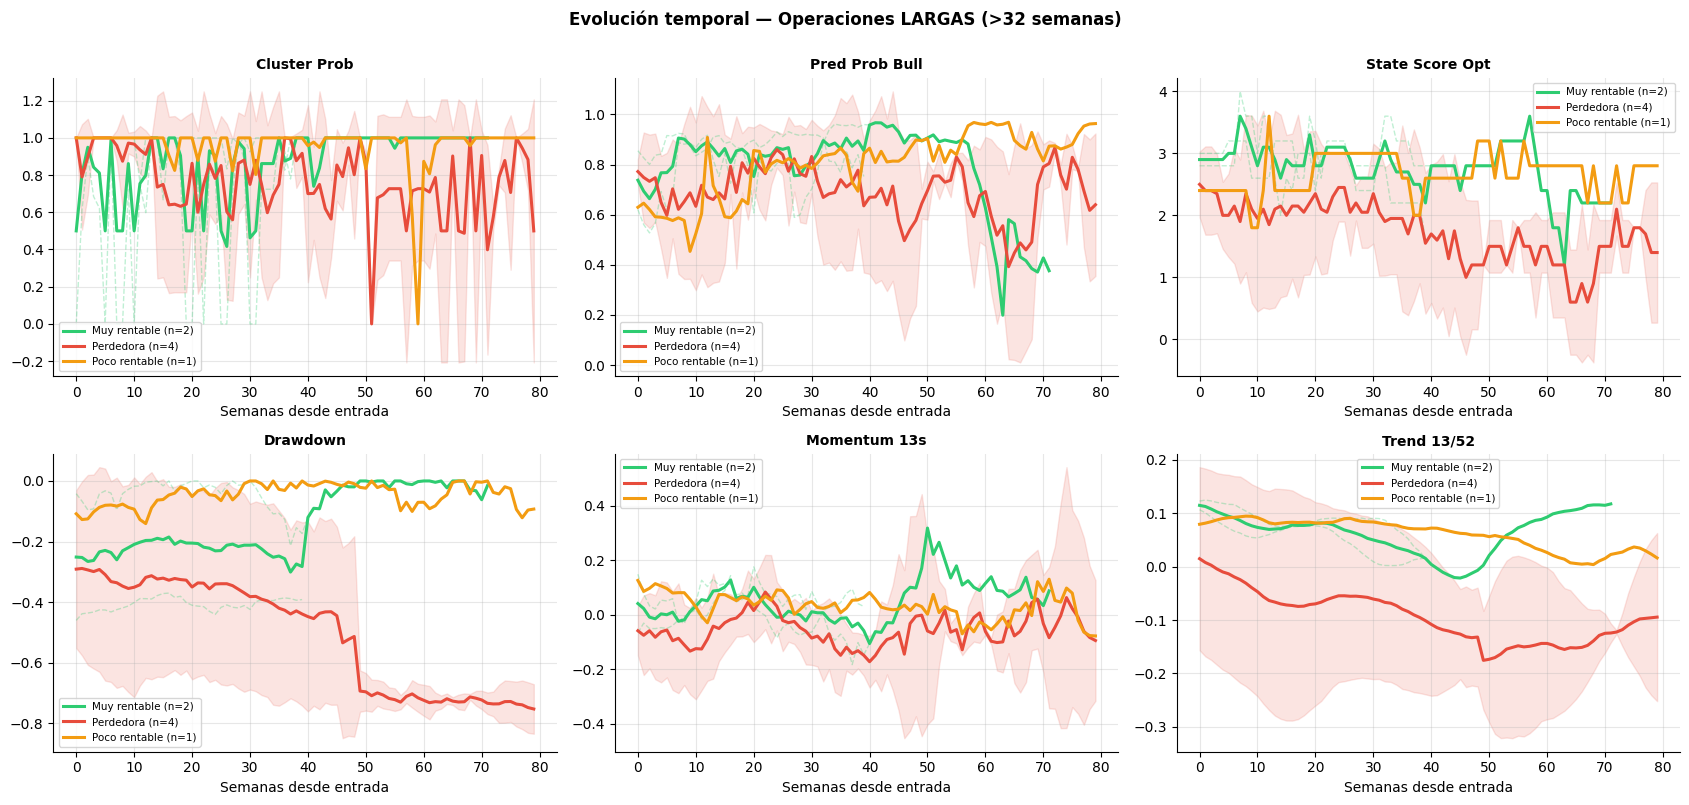

In [47]:
# ============================================================
# SECCIÓN 5 — EVOLUCIÓN TEMPORAL (event-time alignment)
# ============================================================

def build_event_time_panel(panels, trade_ids, variable, max_weeks=80):
    aligned = {}
    for tid in trade_ids:
        if tid in panels and variable in panels[tid].columns:
            aligned[tid] = panels[tid][variable].reset_index(drop=True).iloc[:max_weeks]
    return pd.DataFrame(aligned)

def plot_evolution(ax, panels, groups_dict, variable, title, max_weeks=80):
    for label, (tids, color) in groups_dict.items():
        panel = build_event_time_panel(panels, tids, variable, max_weeks)
        if panel.empty:
            continue
        x = np.arange(len(panel))
        mean_v = panel.mean(axis=1)
        n_v = panel.count(axis=1)
        ax.plot(x, mean_v, color=color, linewidth=2.2, label=f"{label} (n={len(tids)})")
        if panel.shape[1] >= 4:
            std_v = panel.std(axis=1)
            ax.fill_between(x, mean_v - std_v, mean_v + std_v, color=color, alpha=0.15)
        else:
            for col in panel.columns:   # muestra individual si la muestra es pequeña
                ax.plot(x, panel[col], color=color, alpha=0.3, linewidth=1, linestyle="--")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Semanas desde entrada")
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

# ── Foco: dentro de Largas, Muy rentable vs Perdedora ────────
largas_winners = largas[largas["profit_group"] == "Muy rentable"]["trade_id"].tolist()
largas_losers  = largas[largas["profit_group"] == "Perdedora"]["trade_id"].tolist()
largas_weak    = largas[largas["profit_group"] == "Poco rentable"]["trade_id"].tolist()

groups_largas = {"Muy rentable": (largas_winners, GREEN), "Perdedora": (largas_losers, RED)}
if largas_weak:
    groups_largas["Poco rentable"] = (largas_weak, AMBER)

vars_evolution = [("cluster_prob", "Cluster Prob"), ("pred_prob_bull", "Pred Prob Bull"),
                   ("state_score_opt", "State Score Opt"), ("drawdown", "Drawdown"),
                   ("mom_13", "Momentum 13s"), ("trend_13_52", "Trend 13/52")]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (var, title) in zip(axes.flat, vars_evolution):
    plot_evolution(ax, or_panels, groups_largas, var, title)
plt.suptitle("Evolución temporal — Operaciones LARGAS (>32 semanas)", fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

if not largas_winners or not largas_losers:
    print("⚠️  Alguno de los subgrupos (Muy rentable / Perdedora dentro de Largas) "
          "tiene 0 operaciones — esa comparación específica no es posible con el "
          "historial actual. Se reporta explícitamente en vez de omitirlo.")

### Evolución temporal en operaciones de duración media

En la **Sección 2** observamos que las operaciones **Poco rentables** se concentran principalmente dentro del grupo de duración **Media (12–32 semanas)** y prácticamente no aparecen entre las operaciones largas.

Por esta razón, repetimos el análisis de evolución temporal sobre este subconjunto específico.

El objetivo es determinar si estas operaciones siguen una trayectoria propia que las diferencie tanto de las operaciones **Muy rentables** como de las **Perdedoras**, o si simplemente representan un comportamiento intermedio entre ambos extremos.

Este análisis permite evaluar si el patrón observado previamente también se refleja en la evolución temporal de las principales variables internas del modelo.


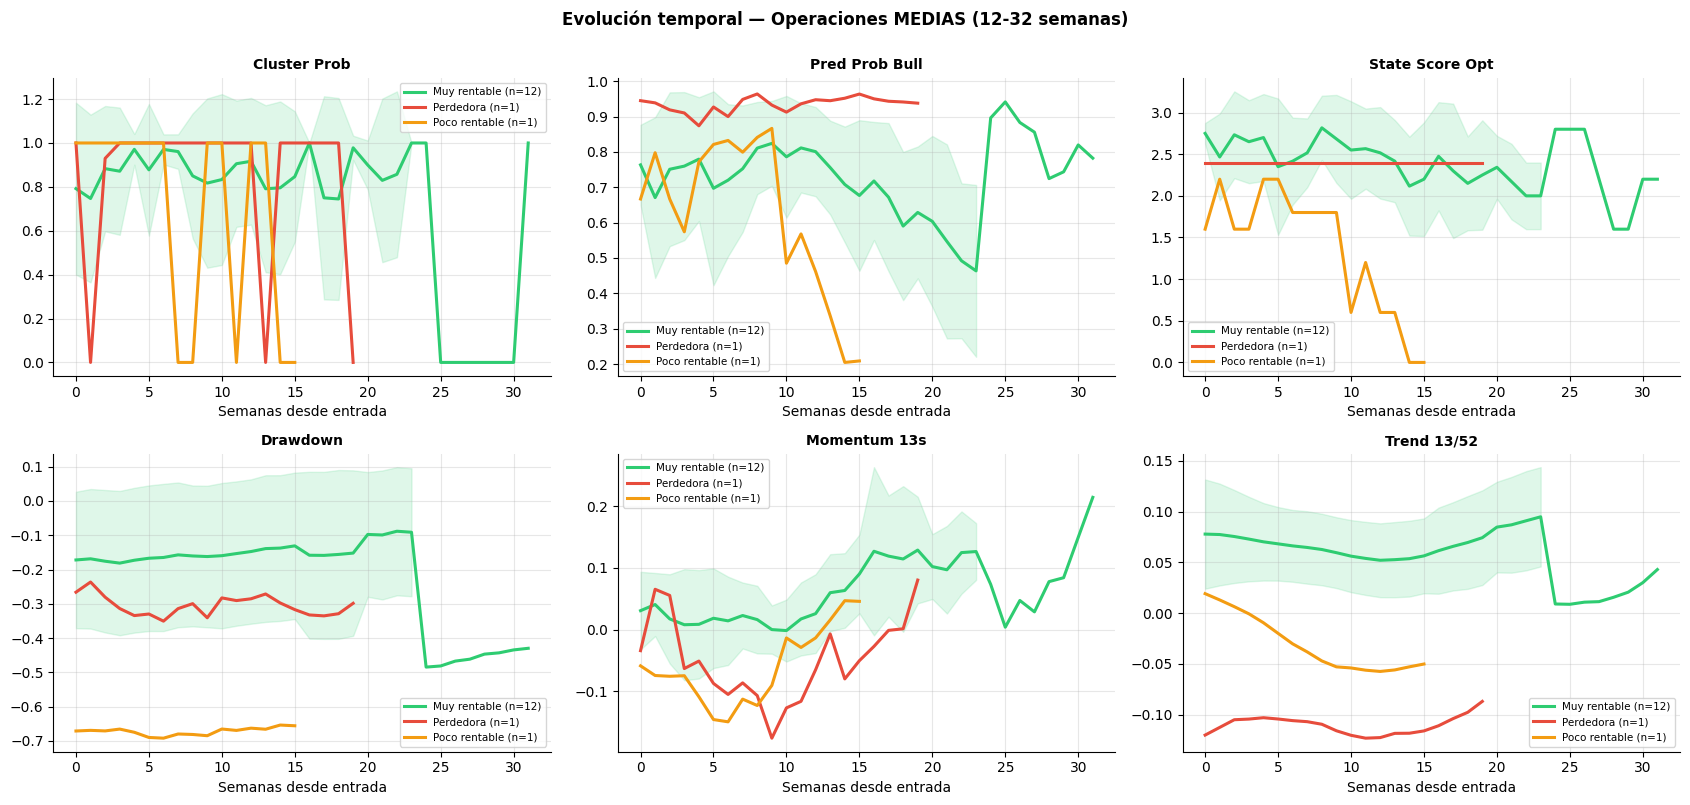

In [48]:
medias = or_trades[or_trades["duration_group"] == "Medias (12-32s)"]
medias_winners = medias[medias["profit_group"] == "Muy rentable"]["trade_id"].tolist()
medias_losers  = medias[medias["profit_group"] == "Perdedora"]["trade_id"].tolist()
medias_weak    = medias[medias["profit_group"] == "Poco rentable"]["trade_id"].tolist()

groups_medias = {"Muy rentable": (medias_winners, GREEN), "Perdedora": (medias_losers, RED)}
if medias_weak:
    groups_medias["Poco rentable"] = (medias_weak, AMBER)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (var, title) in zip(axes.flat, vars_evolution):
    plot_evolution(ax, or_panels, groups_medias, var, title, max_weeks=32)
plt.suptitle("Evolución temporal — Operaciones MEDIAS (12-32 semanas)", fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

# 6️⃣ Diagnóstico del Holding

Hasta este punto hemos estudiado la entrada de las operaciones y la evolución temporal de sus principales variables internas.

La siguiente pregunta se centra directamente en el mecanismo de **holding** implementado por el **OR Champion**:

**¿El holding mantiene abiertas operaciones que, según las señales originales del modelo, ya deberían haberse cerrado?**

Recordemos que el **OR Champion** no cierra inmediatamente una posición cuando desaparecen las señales de entrada. En su lugar, incorpora un período de **holding** que mantiene activa la operación durante algunas semanas adicionales.

Si una fracción importante de la vida de una operación transcurre únicamente gracias a este mecanismo, ello podría indicar que el sistema permanece más tiempo del necesario en el mercado, especialmente en operaciones largas y de baja rentabilidad.

En esta sección cuantificamos cuánto tiempo permanece abierta cada operación exclusivamente por efecto del **holding** y evaluamos si este comportamiento se concentra en determinados grupos de rentabilidad.


% DE TIEMPO EN HOLDING PURO, por grupo de duración:


,mean,median,count
duration_group,,,
Cortas (<12s),0.439,0.500,11
Medias (12-32s),0.268,0.250,14
Largas (>32s),0.130,0.153,7



% DE TIEMPO EN HOLDING PURO, dentro de Largas, por rentabilidad:


,mean,median,count
profit_group,,,
Perdedora,0.106,0.106,4
Poco rentable,0.159,0.159,1
Muy rentable,0.164,0.164,2



SEMANAS SIN NINGÚN RAW SIGNAL AL MOMENTO DEL CIERRE, dentro de Largas:


,trade_id,weeks,profit_group,semanas_sin_raw_al_cierre
0,0,200,Perdedora,3
4,4,100,Perdedora,3
9,9,40,Muy rentable,7
12,12,88,Poco rentable,4
17,17,49,Perdedora,1
24,24,46,Perdedora,1
29,29,72,Muy rentable,6


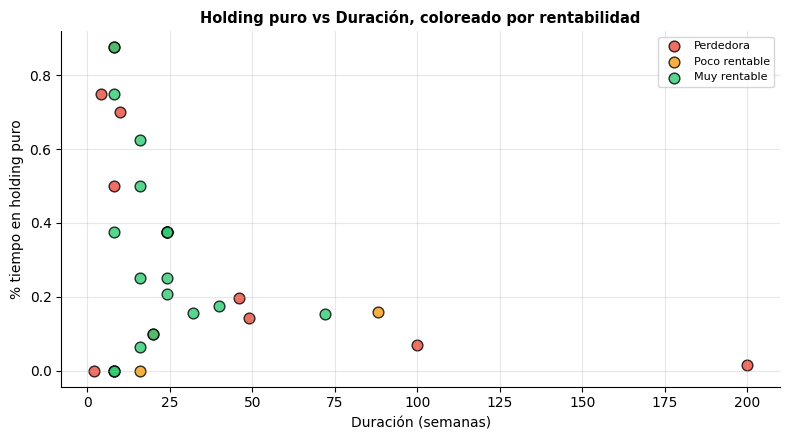

In [49]:
# ============================================================
# SECCIÓN 6 — DIAGNÓSTICO DE HOLDING 
# ============================================================

def pct_pure_holding(panel):
    """Fracción de semanas donde NINGÚN raw signal estaba activo
    (la posición se sostiene solo por el mecanismo de holding)."""
    both_off = (~panel["dd_raw"].astype(bool)) & (~panel["opt_raw"].fillna(False).astype(bool))
    return both_off.mean()

def weeks_to_last_raw_signal(panel):
    """En qué semana (desde el final) ocurrió la última vez que algún raw
    signal estuvo activo. 0 = el raw signal estaba activo hasta el cierre."""
    any_raw = panel["dd_raw"].astype(bool) | panel["opt_raw"].fillna(False).astype(bool)
    if any_raw.any():
        last_true_pos = np.where(any_raw.values)[0][-1]
        return len(panel) - 1 - last_true_pos
    return len(panel)

or_trades["pct_holding_puro"] = or_trades["trade_id"].map(lambda t: pct_pure_holding(or_panels[t]))
or_trades["semanas_sin_raw_al_cierre"] = or_trades["trade_id"].map(
    lambda t: weeks_to_last_raw_signal(or_panels[t]))

print("% DE TIEMPO EN HOLDING PURO, por grupo de duración:")
display(or_trades.groupby("duration_group")["pct_holding_puro"].agg(["mean","median","count"]).round(3))

print("\n% DE TIEMPO EN HOLDING PURO, dentro de Largas, por rentabilidad:")
display(largas.assign(pct=largas["trade_id"].map(lambda t: pct_pure_holding(or_panels[t])))
        .groupby("profit_group")["pct"].agg(["mean","median","count"]).round(3))

print("\nSEMANAS SIN NINGÚN RAW SIGNAL AL MOMENTO DEL CIERRE, dentro de Largas:")
display(largas.assign(s=largas["trade_id"].map(lambda t: weeks_to_last_raw_signal(or_panels[t])))
        [["trade_id","weeks","profit_group","s"]].rename(columns={"s":"semanas_sin_raw_al_cierre"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
for g, c in colors_box.items():
    sub = or_trades[or_trades["profit_group"] == g]
    if len(sub):
        ax.scatter(sub["weeks"], sub["pct_holding_puro"], color=c, label=g, s=60, edgecolor="black", alpha=0.8)
ax.set_xlabel("Duración (semanas)"); ax.set_ylabel("% tiempo en holding puro")
ax.set_title("Holding puro vs Duración, coloreado por rentabilidad", fontsize=10.5, fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 7️⃣ Diagnóstico del Régimen

Hasta este punto sabemos que algunas operaciones permanecen abiertas durante largos períodos y que parte de esa permanencia puede explicarse por el mecanismo de **holding**.

Sin embargo, aún existe una explicación alternativa: que el propio modelo de clasificación de régimen responda con demasiada lentitud al deterioro de las condiciones del mercado.

En otras palabras, una operación podría permanecer abierta no porque el **holding** la mantenga activa, sino porque el sistema continúa clasificando el régimen como favorable durante más tiempo del debido.

Para investigar esta posibilidad analizamos dos aspectos complementarios:

* **Velocidad de cambio de `meta_state`**, para medir cuánto tarda el modelo en abandonar el régimen con el que comenzó la operación.
* **Evolución de `cluster_prob`**, para evaluar si la confianza del modelo comienza a deteriorarse antes de que ocurra el cambio de régimen.

Si ambas señales muestran un deterioro sostenido mientras el régimen permanece sin cambios, existiría evidencia de que el clasificador responde con retraso a los cambios en las condiciones del mercado.


In [50]:
# ============================================================
# SECCIÓN 7 — DIAGNÓSTICO DE RÉGIMEN 
# ============================================================

def weeks_to_first_regime_change(panel):
    entry_state = panel["meta_state"].iloc[0]
    changed = panel["meta_state"] != entry_state
    if changed.any():
        return int(np.where(changed.values)[0][0])
    return len(panel)   # nunca cambió durante la operación

def cluster_prob_trend(panel):
    """Pendiente de cluster_prob a lo largo de la operación (regresión simple
    semana vs valor). Negativa y significativa = caída sostenida."""
    y = panel["cluster_prob"].values
    if len(y) < 5:
        return np.nan, np.nan
    x = np.arange(len(y))
    slope, intercept, r, p, se = stats.linregress(x, y)
    return slope, p

or_trades["semanas_a_cambio_regimen"] = or_trades["trade_id"].map(
    lambda t: weeks_to_first_regime_change(or_panels[t]))
trend_results = or_trades["trade_id"].map(lambda t: cluster_prob_trend(or_panels[t]))
or_trades["cluster_prob_slope"]   = trend_results.map(lambda x: x[0])
or_trades["cluster_prob_slope_p"] = trend_results.map(lambda x: x[1])

print("SEMANAS HASTA EL PRIMER CAMBIO DE meta_state, por duración y rentabilidad:")
display(or_trades.groupby(["duration_group", "profit_group"], observed=True)
        ["semanas_a_cambio_regimen"].agg(["mean", "median", "count"]).round(1))

print("\nEn operaciones LARGAS específicamente:")
display(largas.assign(s=largas["trade_id"].map(lambda t: weeks_to_first_regime_change(or_panels[t])))
        [["trade_id", "weeks", "profit_group", "s"]].rename(columns={"s": "semanas_a_cambio_regimen"}))

print("\nPENDIENTE DE cluster_prob DURANTE LA OPERACIÓN (negativa = cae con el tiempo):")
display(or_trades.groupby("profit_group")[["cluster_prob_slope"]].agg(["mean", "median", "count"]).round(5))

# ── ¿cae cluster_prob SIN que cambie meta_state? ──
print("\nCASOS CON CAÍDA DE cluster_prob (pendiente negativa, p<0.10) "
      "PERO SIN cambio de meta_state durante toda la operación:")
candidatos_c = or_trades[
    (or_trades["cluster_prob_slope"] < 0) &
    (or_trades["cluster_prob_slope_p"] < 0.10) &
    (or_trades["semanas_a_cambio_regimen"] == or_trades["weeks"])
]
if len(candidatos_c):
    display(candidatos_c[["trade_id", "weeks", "return", "profit_group",
                          "cluster_prob_slope", "cluster_prob_slope_p"]])
else:
    print("Ningún caso cumple ambas condiciones simultáneamente en este historial.")

SEMANAS HASTA EL PRIMER CAMBIO DE meta_state, por duración y rentabilidad:


mean  median  count
duration_group  profit_group                      
Cortas (<12s)   Perdedora       2.7     2.0      6
                Muy rentable    7.2     8.0      5
Medias (12-32s) Perdedora       1.0     1.0      1
                Poco rentable   7.0     7.0      1
                Muy rentable   13.9    16.0     12
Largas (>32s)   Perdedora      22.2    19.5      4
                Poco rentable  58.0    58.0      1
                Muy rentable   21.0    21.0      2


En operaciones LARGAS específicamente:


,trade_id,weeks,profit_group,semanas_a_cambio_regimen
0,0,200,Perdedora,1
4,4,100,Perdedora,13
9,9,40,Muy rentable,1
12,12,88,Poco rentable,58
17,17,49,Perdedora,49
24,24,46,Perdedora,26
29,29,72,Muy rentable,41



PENDIENTE DE cluster_prob DURANTE LA OPERACIÓN (negativa = cae con el tiempo):


cluster_prob_slope               
                            mean   median count
profit_group                                   
Perdedora                0.00309 -0.00085     9
Poco rentable           -0.02584 -0.02584     2
Muy rentable            -0.00156  0.00000    19


CASOS CON CAÍDA DE cluster_prob (pendiente negativa, p<0.10) PERO SIN cambio de meta_state durante toda la operación:


,trade_id,weeks,return,profit_group,cluster_prob_slope,cluster_prob_slope_p
18,18,16,0.07553,Muy rentable,-0.004015,0.05067


# 8️⃣ Mercados Laterales

Hasta este punto hemos analizado si las operaciones permanecen abiertas por efecto del **holding** o porque el modelo de **régimen** tarda en reaccionar a los cambios del mercado.

Sin embargo, aún existe una tercera explicación posible: que algunas operaciones nunca lleguen a desarrollarse dentro de una tendencia definida y permanezcan durante varias semanas en un mercado lateral.

En ese escenario, el modelo podría seguir clasificando el régimen como favorable, mientras que el precio avanza demasiado poco para compensar el tiempo que la posición permanece abierta.

Para investigar esta posibilidad comparamos el comportamiento promedio del **momentum** y de la **volatilidad** entre operaciones **Muy rentables**, **Poco rentables** y **Perdedoras**, concentrándonos exclusivamente en operaciones de duración media y larga.


MOMENTUM Y VOLATILIDAD REALIZADOS, por grupo de rentabilidad (Medias + Largas):


,Grupo,N,mom_13_mean,mom_26_mean,vol_13_mean,trend_13_52_mean,|momentum 13s| medio
0,Poco rentable,2,-0.0182,-0.0089,0.0240,0.0114,0.0419
1,Muy rentable,14,0.0474,0.0852,0.0236,0.0647,0.0504
2,Perdedora,5,-0.0250,-0.0331,0.0364,-0.0329,0.0293


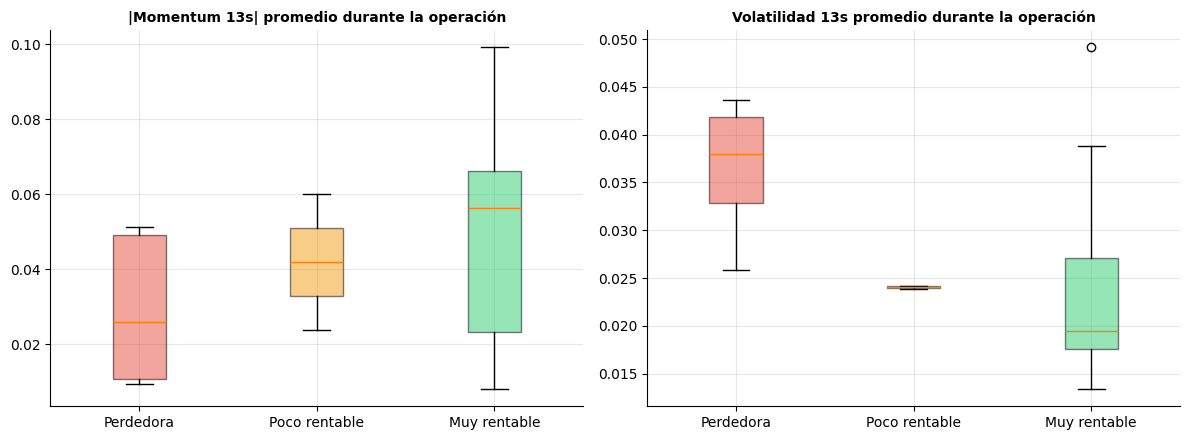


Lectura: si 'Poco rentable' muestra |momentum| sistemáticamente más bajo
que 'Muy rentable' (sin necesariamente menor volatilidad), eso es consistente
con la hipótesis de investigación. Si no hay diferencia clara, no se confirma con esta evidencia.


In [51]:
# ============================================================
# SECCIÓN 8 — MERCADOS LATERALES
# ============================================================

lateral_vars = ["mom_13_mean", "mom_26_mean", "vol_13_mean", "trend_13_52_mean"]
lateral_vars = [v for v in lateral_vars if v in or_trades.columns]

combined = or_trades[or_trades["duration_group"] != "Cortas (<12s)"].copy()  # foco: Medias+Largas
combined["abs_mom_13_mean"] = combined["mom_13_mean"].abs() if "mom_13_mean" in combined else np.nan

rows = []
for g in ["Poco rentable", "Muy rentable", "Perdedora"]:
    sub = combined[combined["profit_group"] == g]
    if len(sub) == 0:
        continue
    row = {"Grupo": g, "N": len(sub)}
    for v in lateral_vars:
        row[v] = sub[v].mean()
    row["|momentum 13s| medio"] = sub["abs_mom_13_mean"].mean() if "abs_mom_13_mean" in sub else np.nan
    rows.append(row)

lateral_summary = pd.DataFrame(rows)
print("MOMENTUM Y VOLATILIDAD REALIZADOS, por grupo de rentabilidad (Medias + Largas):")
display(lateral_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, var, title in [(axes[0], "abs_mom_13_mean", "|Momentum 13s| promedio durante la operación"),
                        (axes[1], "vol_13_mean", "Volatilidad 13s promedio durante la operación")]:
    data = [combined[combined["profit_group"]==g][var if var!="abs_mom_13_mean" else "abs_mom_13_mean"].dropna()
             for g in ["Perdedora","Poco rentable","Muy rentable"] if (combined["profit_group"]==g).sum()>0]
    labels = [g for g in ["Perdedora","Poco rentable","Muy rentable"] if (combined["profit_group"]==g).sum()>0]
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, g in zip(bp["boxes"], labels):
        patch.set_facecolor(colors_box.get(g, MUTED)); patch.set_alpha(0.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\nLectura: si 'Poco rentable' muestra |momentum| sistemáticamente más bajo")
print("que 'Muy rentable' (sin necesariamente menor volatilidad), eso es consistente")
print("con la hipótesis de investigación. Si no hay diferencia clara, no se confirma con esta evidencia.")

# 9️⃣ Señales Tempranas de Pérdidas Extremas

Hasta este punto, todas las comparaciones se han realizado considerando la evolución completa de las operaciones.

Sin embargo, desde una perspectiva operativa surge una última pregunta de investigación:

**¿Las operaciones que terminan siendo las peores ya presentan señales distintivas desde sus primeras semanas, o esas diferencias aparecen únicamente durante su evolución?**

Si las operaciones con pérdidas extremas exhiben características identificables desde las primeras semanas, dichas variables podrían constituir candidatos para futuros filtros de entrada. Por el contrario, si las diferencias aparecen únicamente en etapas posteriores, ello sugeriría que el problema no radica en la selección inicial de las operaciones, sino en la forma en que éstas permanecen abiertas y evolucionan a lo largo del tiempo.


Operaciones extremadamente perdedoras (peores 4):


,trade_id,entry,weeks,return,cagr
0,0,2001-01-26,200,-0.416473,-0.130688
4,4,2008-01-04,100,-0.154083,-0.083335
24,24,2021-10-01,46,-0.111088,-0.124637
8,8,2012-03-30,8,-0.091575,-0.464352



COMPARACIÓN: extremadamente perdedoras vs resto, en semanas 0/4/8:


,Semana,cluster_prob (extremas),cluster_prob (resto),pred_prob_bull (extremas),pred_prob_bull (resto),state_score_opt (extremas),state_score_opt (resto),drawdown (extremas),drawdown (resto),atr_pct (extremas),atr_pct (resto)
0,0,1.0000,0.7996,0.7377,0.7370,2.5000,2.6143,-0.3686,-0.2153,0.0624,0.0344
1,4,0.9487,0.9288,0.6145,0.7189,2.0000,2.5385,-0.3922,-0.2001,0.0736,0.0368
2,8,0.8329,0.8000,0.5699,0.8128,1.9333,2.7579,-0.4317,-0.2230,0.0858,0.0392


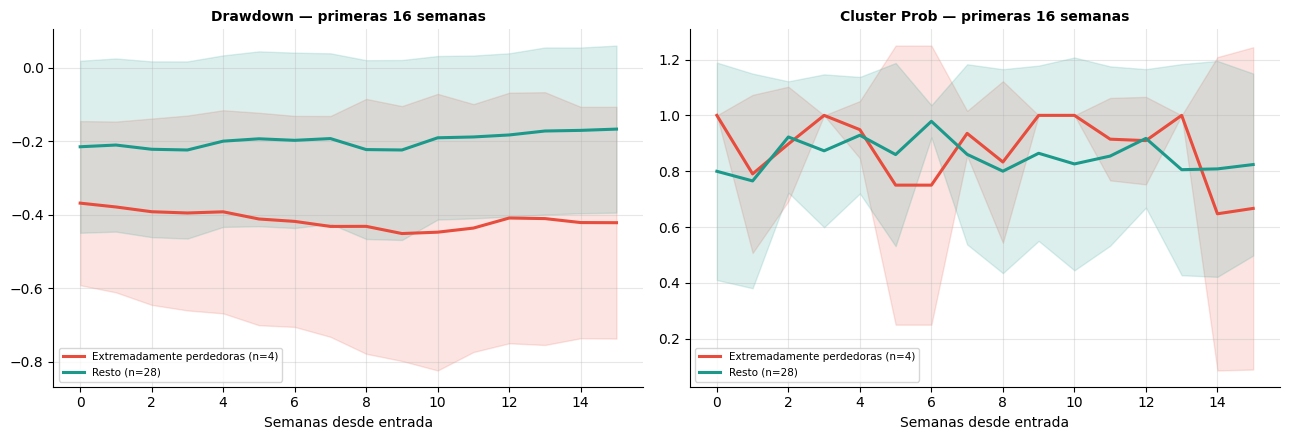

In [52]:
# ============================================================
# SECCIÓN 9 — SEÑALES TEMPRANAS DE PÉRDIDAS EXTREMAS
# ============================================================

N_EXTREME = max(2, int(len(or_trades) * 0.15))   # ~15% peores, mínimo 2
extreme_losers = or_trades.nsmallest(N_EXTREME, "return")
rest = or_trades.drop(extreme_losers.index)

print(f"Operaciones extremadamente perdedoras (peores {N_EXTREME}):")
display(extreme_losers[["trade_id","entry","weeks","return","cagr"]])

def snapshot_at_week(panel, week, var):
    if week < len(panel):
        return panel[var].iloc[week]
    return np.nan

check_vars = [v for v in ["cluster_prob","pred_prob_bull","state_score_opt","drawdown","atr_pct"]
              if v in INTERNAL_VARS]

rows = []
for week in [0, 4, 8]:
    row = {"Semana": week}
    for var in check_vars:
        extreme_vals = extreme_losers["trade_id"].map(lambda t: snapshot_at_week(or_panels[t], week, var))
        rest_vals     = rest["trade_id"].map(lambda t: snapshot_at_week(or_panels[t], week, var))
        row[f"{var} (extremas)"] = extreme_vals.mean()
        row[f"{var} (resto)"]    = rest_vals.mean()
    rows.append(row)

early_comparison = pd.DataFrame(rows)
print("\nCOMPARACIÓN: extremadamente perdedoras vs resto, en semanas 0/4/8:")
display(early_comparison.round(4))

# ── Visual: trayectoria de drawdown y cluster_prob, extremas vs resto ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
extreme_ids = extreme_losers["trade_id"].tolist()
rest_ids    = rest["trade_id"].tolist()
groups_extreme = {"Extremadamente perdedoras": (extreme_ids, RED), "Resto": (rest_ids, TEAL)}
for ax, var, title in [(axes[0], "drawdown", "Drawdown — primeras 16 semanas"),
                        (axes[1], "cluster_prob", "Cluster Prob — primeras 16 semanas")]:
    plot_evolution(ax, or_panels, groups_extreme, var, title, max_weeks=16)
plt.tight_layout(); plt.show()

# 🔟 Timeline Visual de las Operaciones

Tras analizar por separado los distintos componentes del sistema, resulta útil observar todas las operaciones simultáneamente sobre la evolución histórica del **QQQ**.

Esta visualización permite situar cada operación dentro de su contexto de mercado, relacionando su duración y su resultado final con la evolución del activo a lo largo del tiempo.

Las operaciones se representan según su grupo de rentabilidad, facilitando la identificación de patrones que pueden no resultar evidentes al analizar cada componente de forma aislada.


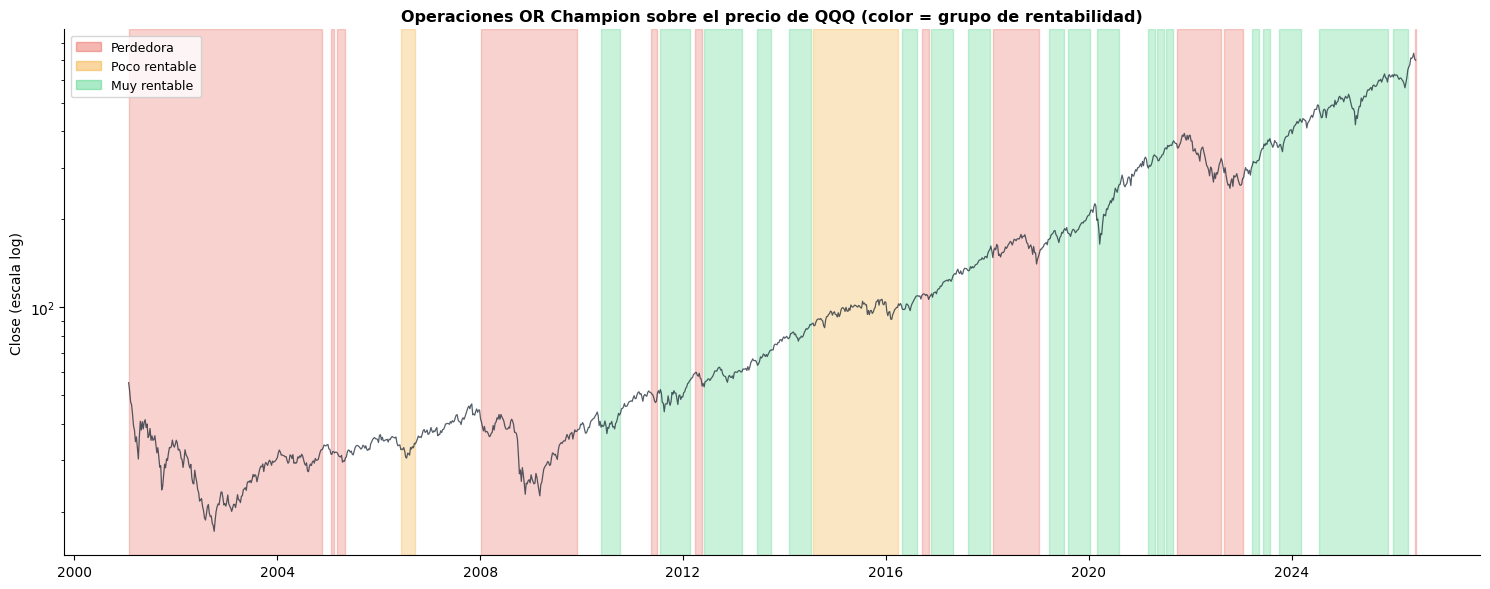

In [53]:
# ============================================================
# SECCIÓN 10 — TIMELINE VISUAL SOBRE EL PRECIO
# ============================================================

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(live_df.index, live_df["Close"], color=NAVY, linewidth=0.9, alpha=0.7, zorder=1)
ax.set_yscale("log")

for _, t in or_trades.iterrows():
    color = colors_box.get(t["profit_group"], MUTED)
    ax.axvspan(t["entry"], t["exit"], color=color, alpha=0.25, zorder=0)

handles = [mpatches.Patch(color=c, alpha=0.4, label=g) for g, c in colors_box.items()]
ax.legend(handles=handles, loc="upper left", fontsize=9)
ax.set_title("Operaciones OR Champion sobre el precio de QQQ (color = grupo de rentabilidad)",
              fontsize=11.5, fontweight="bold")
ax.set_ylabel("Close (escala log)")
plt.tight_layout(); plt.show()

# 1️⃣1️⃣ Conclusiones Finales

In [54]:
# ============================================================
# BLOQUE 11 — CONCLUSIONES FINALES — PARTE 4
# ============================================================

print("""
==============================================================
           CONCLUSIONES FINALES — PARTE 4
==============================================================

1. PUNTO DE PARTIDA DE LA INVESTIGACIÓN

• El OR Champion produce operaciones con duraciones muy distintas,
  pero esa duración, por sí sola, no determina la rentabilidad
  final de cada operación.

• La pregunta central de esta parte fue determinar si las
  diferencias entre operaciones muy rentables, poco rentables y
  perdedoras ya existen desde la entrada o si aparecen durante
  la evolución de la operación.

• La evidencia obtenida indica que la mayor parte de las
  diferencias surge progresivamente durante la vida del trade,
  aunque algunas señales tempranas ya pueden observarse desde las
  primeras semanas.


2. VARIABLES AL MOMENTO DE ENTRADA

• La mayoría de las variables internas presentan distribuciones
  muy similares entre operaciones rentables y perdedoras al
  momento de la entrada.

• drawdown es la variable que muestra la evidencia más consistente
  de diferenciación temprana entre grupos.

• El resto de las variables de entrada (cluster_prob,
  pred_prob_bull, state_score_opt, atr_pct, momentum y tendencia)
  presentan diferencias pequeñas o poco consistentes.

• En consecuencia, la entrada por sí sola explica solo una parte
  del comportamiento posterior de las operaciones.


3. EVOLUCIÓN DENTRO DE LA OPERACIÓN

• Las diferencias entre operaciones aumentan conforme transcurren
  las semanas.

• drawdown se convierte en la variable que mejor refleja esa
  separación, mostrando un deterioro progresivo en las operaciones
  perdedoras mientras permanece considerablemente más estable en
  las operaciones exitosas.

• Las variables asociadas al clasificador de régimen muestran una
  evolución mucho más estable, sugiriendo que la principal fuente
  de divergencia proviene del comportamiento del precio y no del
  sistema de clasificación.


4. DIAGNÓSTICO DEL HOLDING

• El holding sí contribuye a extender la duración de algunas
  operaciones, pero representa solo una fracción de su vida total.

• Incluso las operaciones largas permanecen abiertas
  principalmente porque las condiciones del sistema continúan
  activas y no únicamente por efecto del holding.

• Por lo tanto, el holding no constituye una explicación
  suficiente para las operaciones largas perdedoras observadas.


5. DIAGNÓSTICO DE RÉGIMEN

• El análisis no entrega evidencia de que el clasificador de
  régimen permanezca sistemáticamente retrasado respecto al
  mercado.

• Los cambios de meta_state aparecen tanto en operaciones
  exitosas como perdedoras y no muestran un patrón capaz de
  explicar las anomalías observadas.

• Tampoco se observa una caída consistente de cluster_prob previa
  a las pérdidas, por lo que la evidencia disponible no apunta a
  un problema estructural del clasificador.


6. MERCADOS LATERALES

• Las operaciones poco rentables muestran, en promedio, un
  momentum inferior al observado en las operaciones muy
  rentables.

• Sin embargo, la evidencia disponible es limitada debido al bajo
  número de observaciones y no permite atribuir el fenómeno
  exclusivamente a mercados laterales.

• En otras palabras, los mercados laterales pueden contribuir al
  bajo desempeño de algunas operaciones, pero no constituyen una
  explicación suficiente por sí solos.


7. PÉRDIDAS EXTREMAS

• Las operaciones extremadamente perdedoras muestran señales de
  deterioro identificables desde las primeras semanas.

• Las diferencias aparecen principalmente en drawdown y, de forma
  complementaria, en ATR, mientras que las variables asociadas al
  régimen presentan un comportamiento mucho más parecido al resto
  de las operaciones.

• Esto sugiere que las pérdidas extremas comienzan a manifestarse
  primero en el comportamiento del precio antes que en el
  clasificador de régimen.


8. TIMELINE VISUAL

• La visualización conjunta de todas las operaciones confirma que
  las pérdidas importantes no aparecen completamente al azar.

• Existen períodos históricos donde predominan operaciones
  exitosas y otros donde se concentra una mayor proporción de
  operaciones perdedoras.

• Esto refuerza la importancia del contexto de mercado para
  interpretar el desempeño final de cada operación.


──────────────────────────────────────────────────────────
CONCLUSIÓN GENERAL

• La evidencia obtenida en esta Parte 4 no identifica un único
  mecanismo responsable de las operaciones largas perdedoras, pero
  sí permite descartar varias de las hipótesis inicialmente
  planteadas.

• El holding explica solo una pequeña parte de la duración de las
  operaciones y el clasificador de régimen no muestra evidencia
  de permanecer sistemáticamente retrasado respecto al mercado.

• La evidencia más consistente aparece en las variables ligadas
  al comportamiento del precio, particularmente drawdown y, de
  forma complementaria, ATR.

• En conjunto, los resultados sugieren que las diferencias entre
  operaciones exitosas y perdedoras se originan principalmente en
  la evolución del precio durante la operación, más que en un
  problema del mecanismo de clasificación del régimen.

• En consecuencia, esta Parte 4 no propone todavía nuevas reglas
  operativas para el OR Champion, sino que identifica con mayor
  precisión qué componentes del sistema merecen ser priorizados
  en futuras investigaciones y desarrollos.


──────────────────────────────────────────────────────────
ESTADO DEL PROYECTO

• QQQ Research — Parte 4

• Estado:
    COMPLETADO

• Resultado:
    Se diagnosticó el comportamiento interno del OR Champion,
    evaluando de forma sistemática las principales hipótesis
    planteadas sobre operaciones largas y de baja rentabilidad.

    La evidencia obtenida indica que las anomalías observadas se
    relacionan principalmente con la evolución del precio durante
    la operación, mientras que el holding y el clasificador de
    régimen muestran un papel considerablemente menor en la
    explicación del fenómeno.

==============================================================
""")


           CONCLUSIONES FINALES — PARTE 4

1. PUNTO DE PARTIDA DE LA INVESTIGACIÓN

• El OR Champion produce operaciones con duraciones muy distintas,
  pero esa duración, por sí sola, no determina la rentabilidad
  final de cada operación.

• La pregunta central de esta parte fue determinar si las
  diferencias entre operaciones muy rentables, poco rentables y
  perdedoras ya existen desde la entrada o si aparecen durante
  la evolución de la operación.

• La evidencia obtenida indica que la mayor parte de las
  diferencias surge progresivamente durante la vida del trade,
  aunque algunas señales tempranas ya pueden observarse desde las
  primeras semanas.


2. VARIABLES AL MOMENTO DE ENTRADA

• La mayoría de las variables internas presentan distribuciones
  muy similares entre operaciones rentables y perdedoras al
  momento de la entrada.

• drawdown es la variable que muestra la evidencia más consistente
  de diferenciación temprana entre grupos.

• El resto de las variables de ent